# Stage 01 - Custome CNN

## 1. Config

In [35]:
import os
from pathlib import Path
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, Input
from keras.optimizers import AdamW
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.utils import image_dataset_from_directory

In [12]:
# Seed
SEED = 42

# Cấu hình đường dẫn
PROJECT_ROOT   = Path("..").resolve()
DATASET_ROOT   = PROJECT_ROOT / "datasets/LCC_FASD"
MODELS_DIR     = PROJECT_ROOT / "models"
CHECKPOINT_DIR  = PROJECT_ROOT / "checkpoints/stage-01"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình dữ liệu
IMG_SIZE = 224
NUM_CLASSES = 2
BATCH_SIZE = 32

# Optuna
N_TRIALS = 10
TUNE_EPOCHS = 7
BEST_PARAMS = CHECKPOINT_DIR / "best_params.json"

# Full training
FULL_EPOCHS             = 30
EARLY_STOP_PATIENCE     = 5
LR_SCHEDULER_PATIENCE   = 4
LR_SCHEDULER_FACTOR     = 0.5

# Checkpoint
MODEL1_LATEST_CKPT_PATH = CHECKPOINT_DIR / "model1_custom_cnn_latest.pt"
MODEL1_BEST_CKPT_PATH   = MODELS_DIR / "model1_custom_cnn_best.pt"
HISTORY_CSV_PATH        = CHECKPOINT_DIR / "train_history.csv"
TRAIN_STATE_JSON        = CHECKPOINT_DIR / "training_state.json"

print("✅ Cấu hình hệ thống sẵn sàng!")
print(f"   - DATASET_ROOT           : {DATASET_ROOT}")
print(f"   - MODELS_DIR             : {MODELS_DIR}")
print(f"   - CHECKPOINT_DIR         : {CHECKPOINT_DIR}")
print(f"   - TRAIN_STATE_JSON       : {TRAIN_STATE_JSON}")

✅ Cấu hình hệ thống sẵn sàng!
   - DATASET_ROOT           : /home/dainguyen1506/Documents/Project/face-anti-spoofing/datasets/LCC_FASD
   - MODELS_DIR             : /home/dainguyen1506/Documents/Project/face-anti-spoofing/models
   - CHECKPOINT_DIR         : /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/stage-01
   - TRAIN_STATE_JSON       : /home/dainguyen1506/Documents/Project/face-anti-spoofing/checkpoints/stage-01/training_state.json


In [ ]:
# 1. Đọc dữ liệu Train (bật shuffle để xáo trộn)
print("--- TẬP TRAIN ---")
train_ds = image_dataset_from_directory(
    f'{DATASET_ROOT}/train',
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
class_names = train_ds.class_names

print("\n--- TẬP VALIDATION ---")
val_ds = image_dataset_from_directory(
    f'{DATASET_ROOT}/val',
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\n--- TẬP TEST ---")
test_ds = image_dataset_from_directory(
    f'{DATASET_ROOT}/test',
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 3. Ép tăng tốc bằng Cache và Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\nHoàn tất! Các nhãn (class_names) của bạn là: {class_names}")

--- TẬP TRAIN ---
Found 8299 files belonging to 2 classes.

--- TẬP VALIDATION ---
Found 2948 files belonging to 2 classes.

--- TẬP TEST ---
Found 7580 files belonging to 2 classes.

Hoàn tất! Các nhãn (class_names) của bạn là: ['real', 'spoof']


W0000 00:00:1790933596.716970  143844 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


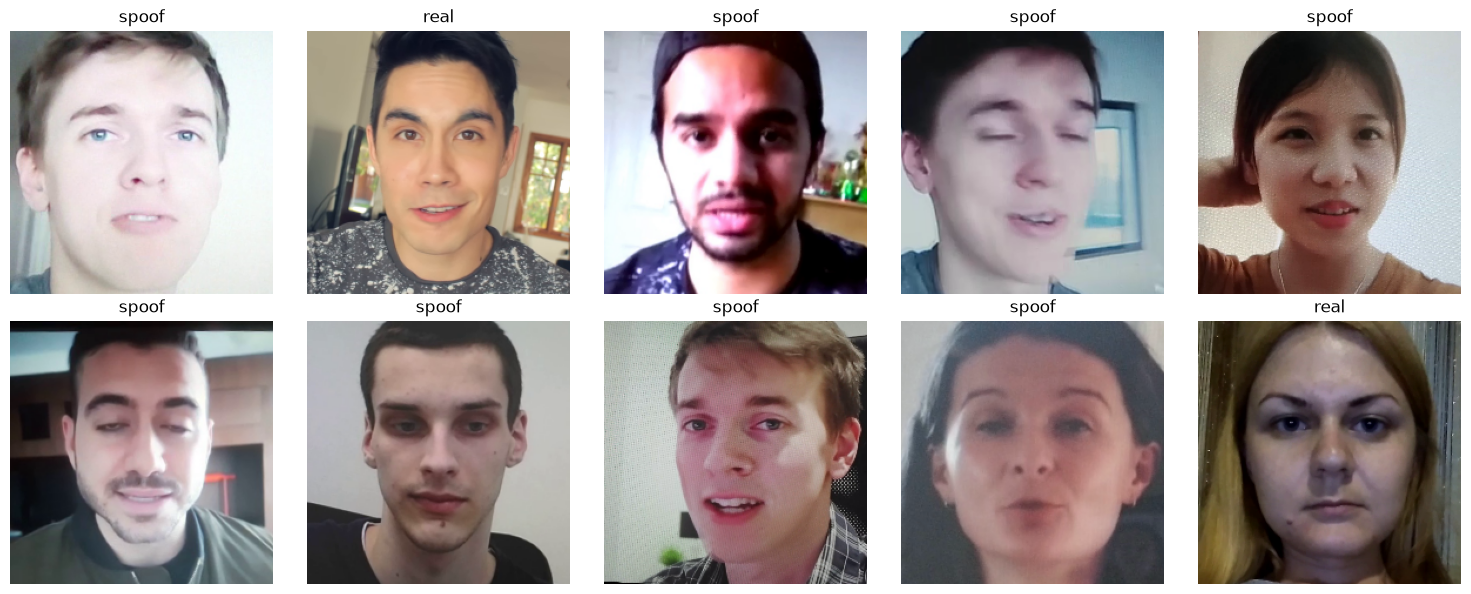

In [28]:
rows = 2
cols = 5
num_images = rows * cols

plt.figure(figsize=(15, 6))

for images, labels in train_ds.take(1):
    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

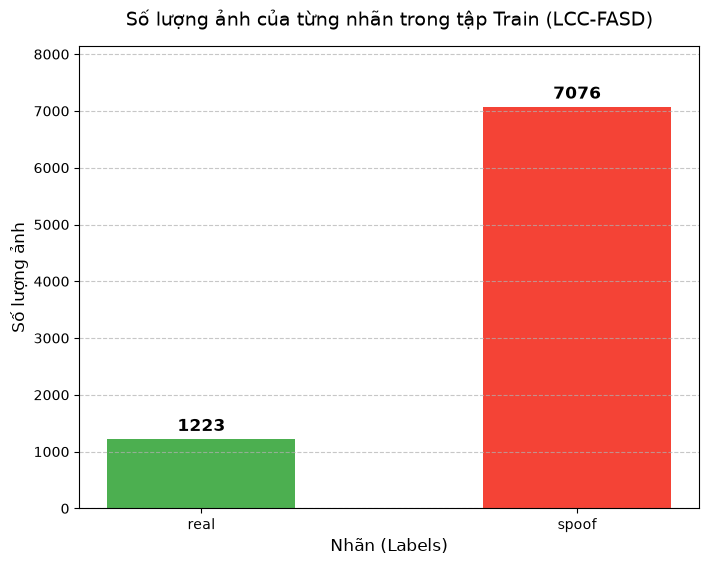

In [ ]:
train_dir = f'{DATASET_ROOT}/train'

# 2. Đếm số lượng ảnh trong từng thư mục nhãn
labels = ['real', 'spoof']
counts = [
    len(os.listdir(os.path.join(train_dir, 'real'))),
    len(os.listdir(os.path.join(train_dir, 'spoof')))
]

# 3. Khởi tạo biểu đồ
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['#4CAF50', '#F44336'], width=0.5)

# 4. Hiển thị con số chi tiết lên đỉnh của từng cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts) * 0.01), 
             f'{int(yval)}', ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

# 5. Định dạng tiêu đề và các trục
plt.title('Số lượng ảnh của từng nhãn trong tập Train (LCC-FASD)', fontsize=14, pad=15)
plt.xlabel('Nhãn (Labels)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.ylim(0, max(counts) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:
# Số lượng lấy trực tiếp từ biểu đồ của bạn
real_count = 1223
spoof_count = 7076
total = real_count + spoof_count

# Công thức chuẩn của scikit-learn / Keras
# weight = (1 / số_lượng_class) * (tổng_số_ảnh / số_class)
weight_for_0 = (1 / real_count) * (total / 2.0)
weight_for_1 = (1 / spoof_count) * (total / 2.0)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Trọng số nhóm Real (0): {weight_for_0:.2f}")
print(f"Trọng số nhóm Spoof (1): {weight_for_1:.2f}")

Trọng số nhóm Real (0): 3.39
Trọng số nhóm Spoof (1): 0.59


## Khởi tạo mô hình

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def build_optimized_fas_model(input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Lớp tiền xử lý & Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.Rescaling(1./255)(x) # Chuẩn hóa pixel về 0-1

    # --- Block 1 ---
    # Sử dụng kernel_regularizer (L2) để kiểm soát trọng số
    x = layers.Conv2D(32, (3, 3), padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x) # Chuẩn hóa ngay sau Conv2D
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --- Block 2 ---
    x = layers.Conv2D(64, (3, 3), padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --- Block 3 ---
    x = layers.Conv2D(128, (3, 3), padding='same', 
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # --- Lớp quyết định (Classification Head) ---
    # Thay thế Flatten bằng GlobalAveragePooling2D để ép nhỏ số lượng tham số
    x = layers.GlobalAveragePooling2D()(x)
    
    # Lớp Dropout loại bỏ ngẫu nhiên 50% nơ-ron
    x = layers.Dropout(0.5)(x)
    
    # Lớp phân loại nhị phân (0: real, 1: spoof)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="FAS_Optimized_CNN")
    return model

# Khởi tạo mô hình
model = build_optimized_fas_model()
model.summary() # In cấu trúc để kiểm tra số lượng tham số

Model: "FAS_Optimized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,273 (368.25 KB)

 Trainable params: 93,825 (366.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# 1. Early Stopping: Dừng sớm nếu mô hình bắt đầu học vẹt (val_loss không giảm)
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,          # Đợi 5 epoch, nếu không cải thiện thì dừng
    restore_best_weights=True # Tự động lấy lại bộ tạ (weights) tốt nhất
)

# 2. ReduceLROnPlateau: Tự động giảm tốc độ học khi mô hình có dấu hiệu chững lại
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,          # Giảm learning rate đi một nửa
    patience=2,          # Nếu 2 epoch không cải thiện thì giảm
    min_lr=1e-6          # Mức learning rate nhỏ nhất cho phép
)

# Compile mô hình (kết hợp Focal Loss nếu cần như đã bàn)
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='binary_crossentropy', # Hoặc BinaryFocalCrossentropy
    metrics=['accuracy']
)

# Khi gọi lệnh fit, truyền callbacks vào
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50, # Cứ đặt lớn, EarlyStopping sẽ tự ngắt
    class_weight=class_weight, # Áp dụng trọng số cân bằng lớp
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50


/home/dainguyen1506/Documents/Project/face-anti-spoofing/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
